<a href="https://colab.research.google.com/github/suddalaharshini3687/literacy_education_analysis/blob/main/literacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the datasets
literacy = pd.read_excel("/content/Table29.6-States.xls")
enrollment = pd.read_csv("/content/UDISE_2021_22_Table_5.17_2.csv.xls")


# Displaying the datasets
print("Literacy Data")
print(literacy.head())

print("\nEnrollment Data")
print(enrollment.head())

Literacy Data
  All India/State/Union Territory  1991 - Male  1991 - Female  1991 - Persons  \
0                       All India           52             64              39   
1                  Andhra Pradesh           44             55              33   
2               Arunachal Pradesh           42             52              30   
3                           Assam           53             62              43   
4                           Bihar           38             51              22   

   2001 - Male  2001 - Female  2001 - Persons  2011 - Rural - Male  \
0           65             75              54                   77   
1           61             70              50                   69   
2           54             64              44                   67   
3           63             71              55                   75   
4           47             60              33                   70   

   2011 - Rural - Female  2011 - Rural - Person  2011 - Urban - Male  \
0     

In [ ]:
literacy.columns=literacy.columns.str.strip()
print(literacy.columns.tolist())

['All India/State/Union Territory', '1991 - Male', '1991 - Female', '1991 - Persons', '2001 - Male', '2001 - Female', '2001 - Persons', '2011 - Rural - Male', '2011 - Rural - Female', '2011 - Rural - Person', '2011 - Urban - Male', '2011 - Urban - Female', '2011 - Urban - Persons']


In [ ]:
# Q1. Calculate average literacy rate

# Rural and Urban Person columns are used because
# they give the overall literacy rate without separating male and female.
literacy["Average"] = literacy[["2011 - Rural - Person", "2011 - Urban - Persons"]].mean(axis=1)

avg_literacy = literacy["Average"].mean()

print("\nQ1: Average Literacy Rate =", round(avg_literacy, 2), "%")



Q1: Average Literacy Rate = 79.94 %


In [ ]:
# Q2. Gender-wise literacy rate

# Male Rural and Male Urban are selected to calculate
# the average literacy rate of males.
male = literacy[
    ["All India/State/Union Territory",
     "2011 - Rural - Male",
     "2011 - Urban - Male"]
]

# Female Rural and Female Urban are selected to calculate
# the average literacy rate of females.
female = literacy[
    ["All India/State/Union Territory",
     "2011 - Rural - Female",
     "2011 - Urban - Female"]
]


male_avg = male[
    ["2011 - Rural - Male", "2011 - Urban - Male"]
].mean().mean()

female_avg = female[
    ["2011 - Rural - Female", "2011 - Urban - Female"]
].mean().mean()

print("\nQ2: Gender-wise Literacy Rate")
print("Male =", round(male_avg, 2), "%")
print("Female =", round(female_avg, 2), "%")


Q2: Gender-wise Literacy Rate
Male = 85.93 %
Female = 73.44 %


In [ ]:
# Q3. Missing values and median

print("\nQ3: Missing Enrollment Values and Median")

# isnull() is used to find empty or missing values
# in the enrollment dataset.
missing = enrollment.isnull().sum().sum()

print("Number of missing values =", missing)

if missing > 0:
    print("Missing values are present in the dataset.")
else:
    print("There are no missing values.")


# Numerical columns are selected because median
# can be calculated only on numerical enrollment data.
numeric_data = enrollment.select_dtypes(include=np.number)

median_enrollment = numeric_data.median().median()

print("Median Enrollment =", round(median_enrollment, 2))


Q3: Missing Enrollment Values and Median
Number of missing values = 0
There are no missing values.
Median Enrollment = 131372.0


In [ ]:
# Q4. Age-wise enrollment

print("\nQ4: Age-wise Enrollment")

# These attributes are selected because they represent
# different age groups of students and help us compare
# enrollment across age categories.
age_columns = [
    "Enrolment of Age Group < 6 years - All - Total",
    "Enrolment of Age Group 6-10 years - All - Total",
    "Enrolment of Age Group 11-13 Years - All - Total",
    "Enrolment of Age Group 14-15 Years - All - Total",
    "Enrolment of Age Group 16-17 years - All - Total",
    "Enrolment of Age Group >17 years - All - Total"
]

for column in age_columns:

    # Convert values into numbers and ignore invalid values.
    total = pd.to_numeric(
        enrollment[column],
        errors="coerce"
    ).sum()

    print(column, "=", total)



Q4: Age-wise Enrollment
Enrolment of Age Group < 6 years - All - Total = 45823448
Enrolment of Age Group 6-10 years - All - Total = 234358896
Enrolment of Age Group 11-13 Years - All - Total = 130116470
Enrolment of Age Group 14-15 Years - All - Total = 70503784
Enrolment of Age Group 16-17 years - All - Total = 42050436
Enrolment of Age Group >17 years - All - Total = 7618626


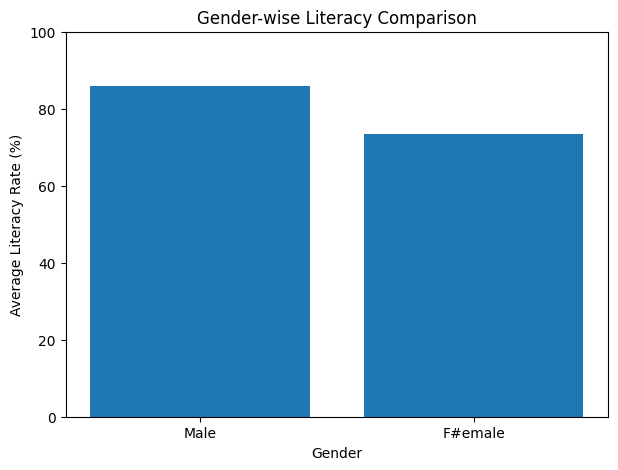

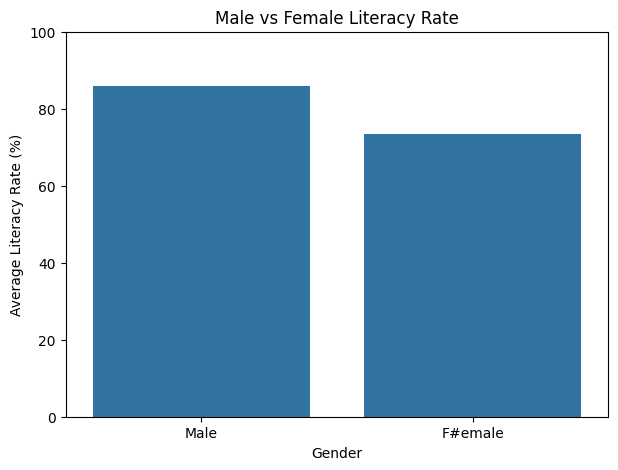

In [ ]:
 #Q5. Gender-wise literacy graph

# Male and Female are used as categories
# and their average literacy rates are used as values.
gender = ["Male", "F#emale"]
values = [male_avg, female_avg]

plt.figure(figsize=(7, 5))

plt.bar(gender, values)

plt.title("Gender-wise Literacy Comparison")
plt.xlabel("Gender")
plt.ylabel("Average Literacy Rate (%)")

# Literacy rate cannot normally exceed 100%.
plt.ylim(0, 100)

plt.savefig("gender_literacy_comparison.png")

plt.show()


# Seaborn graph

# Seaborn is used to create a simple statistical bar graph.
plt.figure(figsize=(7, 5))

sns.barplot(x=gender, y=values)

plt.title("Male vs Female Literacy Rate")
plt.xlabel("Gender")
plt.ylabel("Average Literacy Rate (%)")

plt.ylim(0, 100)

plt.savefig("gender_literacy_seaborn.png")

plt.show()


In [ ]:
# NumPy analysis

# NumPy array is used for numerical calculations.
literacy_values = np.array(values)

print("\nNumPy Analysis")

print(
    "Highest Gender Literacy Rate =",
    round(np.max(literacy_values), 2),
    "%"
)

print(
    "Lowest Gender Literacy Rate =",
    round(np.min(literacy_values), 2),
    "%"
)

print("\nAnalysis completed successfully.")


NumPy Analysis
Highest Gender Literacy Rate = 85.93 %
Lowest Gender Literacy Rate = 73.44 %

Analysis completed successfully.
